In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("E:/ml-models/Supervised/classification/datasets/emails.csv")

In [3]:
df.shape

(5728, 2)

In [4]:
df.sample(19)

,text,spam
1988,Subject: re : houston visit thank you very mu...,0
3723,Subject: slides for jeff ' s presentation all...,0
3235,Subject: @ jones : news and information from t...,0
4840,Subject: re : panel session at 2001 pes summer...,0
5689,"Subject: tanya ' s trip to stanford shirley ,...",0
3057,Subject: year end 2000 performance feedback n...,0
2949,"Subject: gone tuesday vince , a reminder tha...",0
3439,"Subject: re : copy room kevin , you have ful...",0
3213,Subject: re : prospective 6 / 22 houston visit...,0
5055,"Subject: fyi = re : color copier kevin , upd...",0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [6]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [7]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

In [8]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [9]:
df.notnull().sum()

text    5728
spam    5728
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(33)

In [11]:
df=df.drop_duplicates(keep='first')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.reset_index(inplace=True, drop=True)

In [14]:
df.shape

(5695, 2)

In [15]:
percentage= df['spam'].value_counts(normalize=True)*100
percentage

spam
0    75.978929
1    24.021071
Name: proportion, dtype: float64

In [16]:
import matplotlib.pyplot as plt

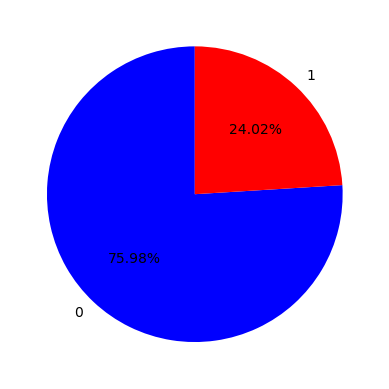

In [17]:
plt.pie(percentage,labels=df['spam'].value_counts().index , autopct='%1.2f%%' , colors=['blue','red'] , startangle=90)
plt.show()

In [18]:
# plt.figure()
# plt.pie( df['spam'].value_counts(), labels=df['spam'].value_counts().index , autopct='%1.2f%%' )
# plt.show()

In [19]:
!pip install nltk

In [20]:
#pip list

In [21]:
import nltk

In [22]:
nltk.download('punkt') #Meaning = Download a pre-built tokenizer model from NLTK,  required for tokenization
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shrey\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shrey\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shrey\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
# Tokenization

In [24]:
df['char'] = df['text'].apply(len)

In [25]:
df.head()

,text,spam,char
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [26]:
df['words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [27]:
df.head()

,text,spam,char,words
0,Subject: naturally irresistible your corporate...,1,1484,325
1,Subject: the stock trading gunslinger fanny i...,1,598,90
2,Subject: unbelievable new homes made easy im ...,1,448,88
3,Subject: 4 color printing special request add...,1,500,99
4,"Subject: do not have money , get software cds ...",1,235,53


In [28]:
df['sentences']=df['text'].apply(lambda x : len( nltk.sent_tokenize(x)))

In [29]:
df['sentences']

0       11
1        1
2        4
3        5
4        9
        ..
5690     7
5691    28
5692    30
5693     6
5694    35
Name: sentences, Length: 5695, dtype: int64

In [30]:
df.head()

,text,spam,char,words,sentences
0,Subject: naturally irresistible your corporate...,1,1484,325,11
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1
2,Subject: unbelievable new homes made easy im ...,1,448,88,4
3,Subject: 4 color printing special request add...,1,500,99,5
4,"Subject: do not have money , get software cds ...",1,235,53,9


In [31]:
df.describe()

,spam,char,words,sentences
count,5695.000000,5695.000000,5695.000000,5695.000000
mean,0.240211,1558.067076,328.214047,19.462511
std,0.427249,2047.078711,419.654234,35.981993
min,0.000000,13.000000,3.000000,1.000000
25%,0.000000,508.500000,102.000000,7.000000
50%,0.000000,979.000000,211.000000,12.000000
75%,0.000000,1893.000000,403.000000,22.000000
max,1.000000,43952.000000,8479.000000,1565.000000


In [32]:
#

In [33]:
df[df['spam']==0][['char','words','sentences']].describe()

,char,words,sentences
count,4327.000000,4327.000000,4327.000000
mean,1634.200139,347.283799,19.838225
std,1965.016383,407.227757,38.124564
min,13.000000,3.000000,1.000000
25%,577.500000,120.000000,7.000000
50%,1122.000000,240.000000,13.000000
75%,2037.500000,440.500000,22.000000
max,43952.000000,8479.000000,1565.000000


In [34]:
df[df['spam']==1][['char' , 'words' , 'sentences']].describe()

,char,words,sentences
count,1368.000000,1368.000000,1368.000000
mean,1317.257310,267.896199,18.274123
std,2271.372893,451.623124,28.130434
min,18.000000,5.000000,1.000000
25%,401.500000,80.000000,6.000000
50%,693.500000,141.000000,11.000000
75%,1250.250000,252.000000,18.000000
max,28432.000000,6131.000000,438.000000


In [35]:
import seaborn as sns

<Axes: xlabel='char', ylabel='Count'>

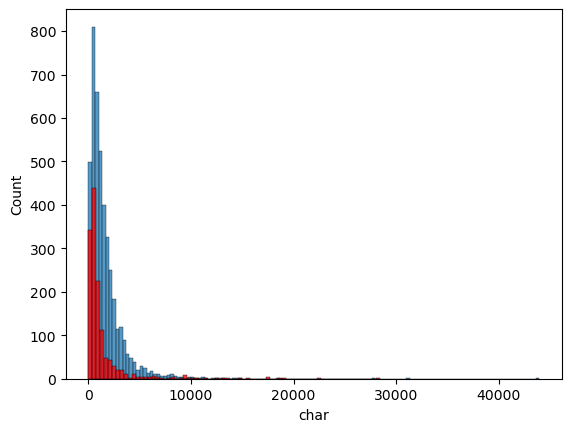

In [36]:
sns.histplot(df[df['spam']==0]['char'])
sns.histplot(df[df['spam']==1]['char'] , color='red')

<Axes: xlabel='words', ylabel='Count'>

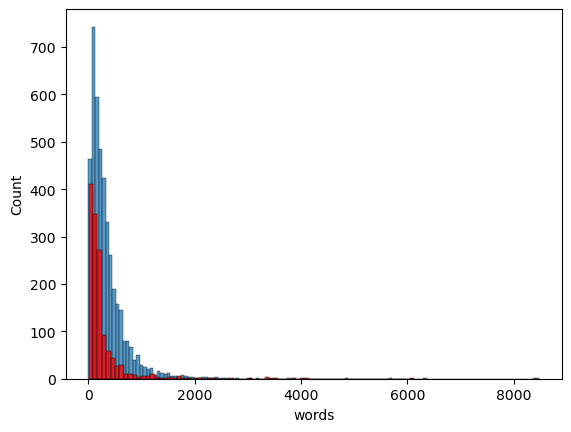

In [37]:
sns.histplot(df[df['spam']==0]['words'])
sns.histplot(df[df['spam']==1]['words'], color='red')

<Axes: xlabel='sentences', ylabel='Count'>

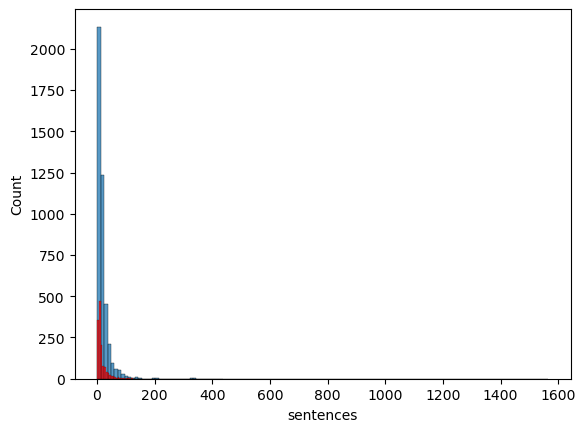

In [38]:
sns.histplot(df[df['spam']==0]['sentences'])
sns.histplot(df[df['spam']==1]['sentences'],color='red')

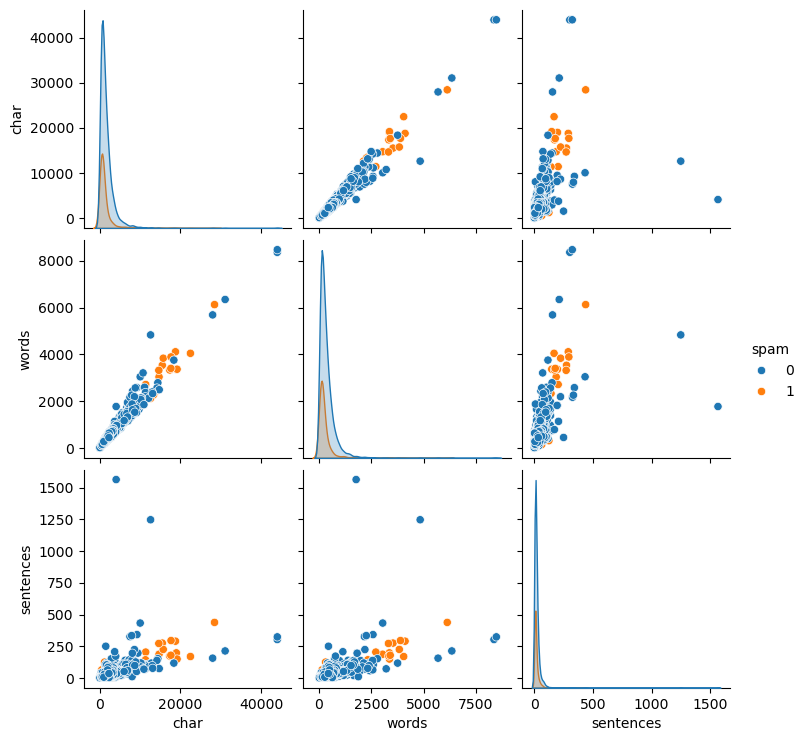

In [39]:
sns.pairplot(df,hue='spam')

In [40]:
df[['char','words','sentences']].corr()

,char,words,sentences
char,1.000000,0.986019,0.595728
words,0.986019,1.000000,0.660311
sentences,0.595728,0.660311,1.000000


<Axes: >

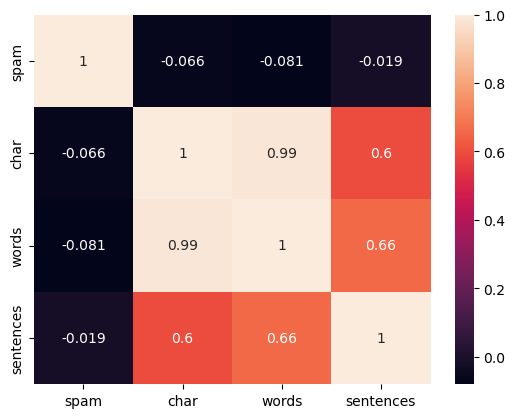

In [41]:
sns.heatmap(df[['spam','char','words','sentences' ]].corr(),annot=True)

In [42]:
#df.loc[0 , 'text']
#df.columns
#df.iloc[0, 0]
#df.iloc[0, df.columns.get_loc('text')]

# Feature Engineering.

### Text Preprocessing 
##### 1.Lower case
##### 2.Tokenization
##### 3. removing Non-Alphabetic Tokens
##### 4. removing stop words
##### 5. Stemming
##### 6. Converting  processed words back into a single string


In [43]:

from nltk.corpus import stopwords  # provides list of useless/common words

# Import tokenizer (to split sentence into words)
from nltk.tokenize import word_tokenize  # used for breaking text into tokens (words)

# Import Porter Stemmer (to reduce words to root form)
from nltk.stem.porter import PorterStemmer  # used for stemming (e.g., playing -> play)

# Download required datasets (run only once)
    
nltk.download('stopwords')  # required for stopword list

# Initialize stemmer object
ps = PorterStemmer()  # create stemmer instance


def text_transform(text):
    
    # 1. Convert text to lowercase (for uniformity)
    text = text.lower()
    
    # 2. Tokenization (convert sentence into list of words)
    words = word_tokenize(text)
    
    # 3. Load stopwords (common useless words)
    stop_words = stopwords.words('english')
    
    # 4. Remove stopwords and non-alphabetic tokens + apply stemming
    cleaned_words = []
    
    for word in words:
        if word.isalpha() and word not in stop_words:  # keep only useful words
            stemmed_word = ps.stem(word)  # convert word to root form
            cleaned_words.append(stemmed_word)
    
    # 5. Join words back into a single string (required for vectorization)
    return " ".join(cleaned_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shrey\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [44]:
text_transform('SHREYASH* IS ^ GOOD BOY# and ')

'shreyash good boy'

In [45]:
df['transformed_text'] = df['text'].apply(text_transform)

In [46]:
df.head()

,text,spam,char,words,sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,99,5,subject color print special request addit info...
4,"Subject: do not have money , get software cds ...",1,235,53,9,subject money get softwar cd softwar compat gr...


## Wordcloud

In [47]:
!pip install wordcloud
from wordcloud import WordCloud
wc = WordCloud(width=2000 , height=1000 , min_font_size=15 , background_color='black')

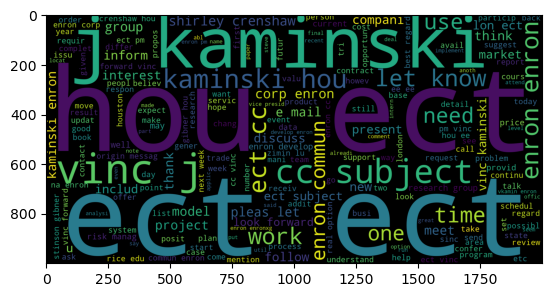

In [48]:
ham_wc = wc.generate(df[df['spam'] == 0]['transformed_text'].str.cat(sep=''))
plt.imshow(ham_wc)

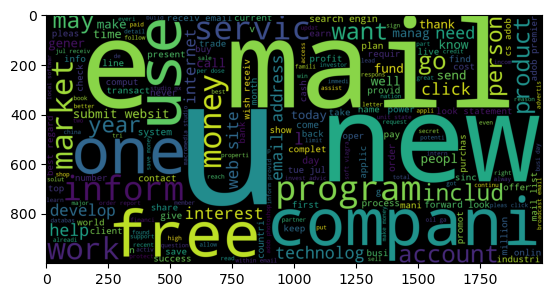

In [49]:
spam_wc = wc.generate(df[df['spam'] == 1]['transformed_text'].str.cat(sep=''))
plt.imshow(spam_wc)

# Model building

In [50]:
#bag of words
# dfidf
#word to vec

# will use bag of words

In [51]:
from sklearn.feature_extraction.text import CountVectorizer # , TfidfVectorizer
cv = CountVectorizer()
# tfidf = TfidfVectorizer()

In [52]:
cv

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [53]:
X= cv.fit_transform(df['transformed_text']).toarray()

In [54]:
# from sklearn.preprocessing import MinMaxScaler
# scalar = MinMaxScaler()
# X = scalar.fit_transform(X)

In [55]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5695, 25605))

In [56]:
X.shape

(5695, 25605)

In [57]:
y = df['spam'].values

In [58]:
y

array([1, 1, 1, ..., 0, 0, 0], shape=(5695,))

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
x_train,x_test,y_train,y_test = train_test_split(X,y, test_size=0.2 , random_state=14)

In [61]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , classification_report

In [62]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [63]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(f"accuracy_score: {accuracy_score(y_test ,  y_pred1)}\n")
print(f"confusion_matrix: {confusion_matrix(y_test ,  y_pred1)}\n")
print(f"precision_score{precision_score(y_test ,  y_pred1)}\n")
print(f"{classification_report(y_test ,  y_pred1)}\n")


accuracy_score: 0.9604916593503073

confusion_matrix: [[842  17]
 [ 28 252]]

precision_score0.9368029739776952

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       859
           1       0.94      0.90      0.92       280

    accuracy                           0.96      1139
   macro avg       0.95      0.94      0.95      1139
weighted avg       0.96      0.96      0.96      1139




In [64]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(f"accuracy_score: {accuracy_score(y_test ,  y_pred2)}\n")
print(f"confusion_matrix: {confusion_matrix(y_test ,  y_pred2)}\n")
print(f"precision_score{precision_score(y_test ,  y_pred2)}")
print(f"classification_report: {classification_report(y_test ,  y_pred2)}\n")

accuracy_score: 0.9920983318700615

confusion_matrix: [[853   6]
 [  3 277]]

precision_score0.9787985865724381
classification_report:               precision    recall  f1-score   support

           0       1.00      0.99      0.99       859
           1       0.98      0.99      0.98       280

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139




In [65]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(f"accuracy_score: {accuracy_score(y_test ,  y_pred3)}\n")
print(f"confusion_matrix: {confusion_matrix(y_test ,  y_pred3)}\n")
print(f"precision_score{precision_score(y_test ,  y_pred3)}")
print(f"classification_report: {classification_report(y_test ,  y_pred3)}\n")


accuracy_score: 0.9850746268656716

confusion_matrix: [[854   5]
 [ 12 268]]

precision_score0.9816849816849816
classification_report:               precision    recall  f1-score   support

           0       0.99      0.99      0.99       859
           1       0.98      0.96      0.97       280

    accuracy                           0.99      1139
   macro avg       0.98      0.98      0.98      1139
weighted avg       0.99      0.99      0.99      1139




In [66]:
## Best Model is MultinomialNB and CountVectorizer since 
# Highest Recall
#  High Precision 
#  Highest F1-score

# ml pipeline

In [67]:
#preprocess fuction
#vectorize
#algo apply

In [68]:
import pickle
pickle.dump(cv , open('Vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))
